# How to Access MERRA-2 Data using OPeNDAP with Python and Calculate Daily/Weekly/Monthly Statistics from Hourly Data

### Timing

Exercise: 5 minutes

### Overview

This Python example code demonstrates how to OPeNDAP to access the Modern-Era Retrospective analysis for Research and Applications, Version 2 (MERRA-2) aerosol diagnostics collection M2T1NXAER.5.12.4 in this example. This collection is 1-hourly time-averaged single-level global aerosol assimilation and archived in daily files with 24 hourly time slices in each file (481 MB per file/day and 14.6 GB per month). For demonstration, we only read 12-day data (i.e., the first 12 days in January 2020) remotely through OPeNDAP URL. We also demonstrate how to calculate the daily/weekly/monthly statistics from hourly data and visualize the evolution of Australian bushfire in January 2020. Figures 1 and 2 are the example images generated by the Python code below, in which the total aerosol extinction (AOT) is plotted as an indicator of the aerosol loading in atmosphere. 

### Prerequisites

This notebook was written using Python 3.10, and requires:
- Valid [Earthdata Login credentials](https://urs.earthdata.nasa.gov), and the generation of [Earthdata Prerequisite Files](https://disc.gsfc.nasa.gov/information/howto?title=How%20to%20Generate%20Earthdata%20Prerequisite%20Files) including the <code>.netrc</code> and `.dodsrc` files.
- [Xarray](https://docs.xarray.dev/en/stable/)
- [NumPy](https://numpy.org/)
- [earthaccess](https://earthaccess.readthedocs.io/en/latest/)
- [Matplotlib](https://matplotlib.org/)
- [Cartopy](https://scitools.org.uk/cartopy/docs/latest/)

#### Anaconda Environment YAML:

It is *strongly recommended* to run this notebook using the ['nasa-gesdisc-opendap' YAML file](https://github.com/nasa/gesdisc-tutorials/tree/main/environments/nasa-gesdisc-opendap.yml) provided in the 'environments' subfolder.

Please follow the instructions [here](https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html#creating-an-environment-from-an-environment-yml-file) to install and activate this environment. 

### 1. Import Libraries and Authenticate with Earthdata Login

In [1]:
import warnings
warnings.filterwarnings("ignore")
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from calendar import monthrange
import time
import earthaccess

# Authenticate with Earthdata Login username and password:
auth = earthaccess.login(strategy="interactive", persist=True)

### 2. Remotely access the hourly MERRA-2 files through OPeNDAP URL (Please refer to "How to obtain the URL of OPeNDAP served dataset"). 

In this cell below, we create a query for the first 12 days in January 2020, and concatenate all of the OPeNDAP URLs into a single Xarray dataset.

In [9]:
# Create search query for OPeNDAP URLs
results = earthaccess.search_data(
    short_name="M2T1NXAER",
    version='5.12.4',
    temporal=('2020-01-01', '2020-01-12'),
    bounding_box=(-180, 0, 180, 90)
)

# Parse out URL from request, add to OPeNDAP URLs list for querying multiple granules with constraint expressions
opendap_urls = []
for item in results:
    for urls in item['umm']['RelatedUrls']:  # Iterate over RelatedUrls in each request step
        if 'OPENDAP' in urls.get('Description', '').upper():  # Check if 'OPENDAP' is in the Description
            # Extract URL
            url = urls['URL']
            # Add URL to list
            opendap_urls.append(url)

try:
    # Load dataset object and metadata, but don't open the values yet
    ds = xr.open_mfdataset(opendap_urls)
except OSError as e:
    print('Error', e)
    print('Please check that your .netrc and .dodsrc files are generated and stored correctly, or that your username/password were entered correctly.')
    raise

In [ ]:
# Print contents of the Xarray dataset
ds

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 288, lat: 361, lon: 576)
Coordinates:
  * lon        (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * time       (time) datetime64[ns] 2kB 2020-01-01T00:30:00 ... 2020-01-12T2...
  * lat        (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
Data variables: (12/50)
    DUEXTTAU   (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    BCFLUXU    (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    OCFLUXV    (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    BCANGSTR   (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    SUFLUXV    (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    SSSMASS25  (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    ...         ...
    SO2SMASS   (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    SSANGSTR   (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    DUEXTT25   (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    OCFLUXU    (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    OCSCATAU   (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
    TOTSCATAU  (time, lat, lon) float32 240MB dask.array<chunksize=(24, 361, 576), meta=np.ndarray>
Attributes: (12/35)
    History:                             Original file generated: Mon Jan 13 ...
    Comment:                             GMAO filename: d5124_m2_jan10.tavg1_...
    Filename:                            MERRA2_400.tavg1_2d_aer_Nx.20200101.nc4
    Conventions:                         CF-1
    Institution:                         NASA Global Modeling and Assimilatio...
    References:                          http://gmao.gsfc.nasa.gov
    ...                                  ...
    RangeEndingTime:                     23:59:59.000000
    build_dmrpp_metadata.build_dmrpp:    3.21.0-272
    build_dmrpp_metadata.bes:            3.21.0-272
    build_dmrpp_metadata.libdap:         libdap-3.21.0-70
    build_dmrpp_metadata.configuration:  \n# TheBESKeys::get_as_config()\nAll...
    build_dmrpp_metadata.invocation:     build_dmrpp -c /tmp/bes_conf_gQ70 -f...

### 3. Select your interested variables and extract it from the whole dataset. 

In this cell, we chose "TOTEXTTAU" (Total Aerosol Extinction) at 550nm as an indicator of the aerosol loading in atmosphere.

In [11]:
# ---------------------------------------------------
# Select your interested variable (e.g., TOTEXTTAU)
# ---------------------------------------------------
sel_var_shortname = "TOTEXTTAU"
sel_var_value= ds[sel_var_shortname]
sel_var_longname = sel_var_value.attrs['long_name']
sel_var_unit = '('+sel_var_value.attrs['units']+')' 
print("The selected variable is {}: {}{}".format(sel_var_shortname, sel_var_longname,sel_var_unit))

The selected variable is TOTEXTTAU: Total Aerosol Extinction AOT [550 nm](1)


### 4. Calculate the daily/weekly/monthly statistics from hourly data

Get the daily mean

In [12]:
# ---------------------------------------------------------------------------------------------------------
# Resample hourly files into daily, weekly, and monthly files and calculate their corresponding statistics,
# e.g., mean, sum, maximum, and minimum.  
# ---------------------------------------------------------------------------------------------------------

# Functions used to calculate various statistics
# ===================================
# Purpose           Function
# 
# mean of dim       mean
# sum of dim        sum
# max of dim        max
# min of dim        min
# ==================================

# Daily mean (i.e., the averaged value over a day at each grid)
sel_var_daily_mean = sel_var_value.resample(time="1D").mean(dim='time', skipna=True)
sel_var_daily_mean

<xarray.DataArray 'TOTEXTTAU' (time: 12, lat: 361, lon: 576)> Size: 10MB
dask.array<stack, shape=(12, 361, 576), dtype=float32, chunksize=(1, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * time     (time) datetime64[ns] 96B 2020-01-01 2020-01-02 ... 2020-01-12
Attributes:
    long_name:       Total Aerosol Extinction AOT [550 nm]
    units:           1
    fmissing_value:  1000000000000000.0
    standard_name:   Total Aerosol Extinction AOT [550 nm]
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

Get the weekly maximum. Note that it is calendar week, starting from Monday to Sunday of each week. Only available data are counted towards each week. For example, for the first week of 2020, it only counts Jan. 1, 2020 (Wed.), which is the first day read in, to Jan. 5, 2020 (Sun.).

In [13]:
%%time
# Weekly maximum (i.e., the maximum of each week at each grid)
sel_var_weekly_max = sel_var_value.resample(time="1w").max(dim='time', skipna=True)
sel_var_weekly_max

CPU times: user 14.4 ms, sys: 1.18 ms, total: 15.5 ms
Wall time: 15.4 ms


<xarray.DataArray 'TOTEXTTAU' (time: 2, lat: 361, lon: 576)> Size: 2MB
dask.array<stack, shape=(2, 361, 576), dtype=float32, chunksize=(1, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * time     (time) datetime64[ns] 16B 2020-01-05 2020-01-12
Attributes:
    long_name:       Total Aerosol Extinction AOT [550 nm]
    units:           1
    fmissing_value:  1000000000000000.0
    standard_name:   Total Aerosol Extinction AOT [550 nm]
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

Get monthly total (it doesn't have any physical meaning for this case, AOT. The sum is useful for mass related variable, such as precipitation)

In [14]:
%%time
# e.g., monthly total (i.e., the total amount over a month at each grid)
sel_var_monthly_total = sel_var_value.resample(time='m').sum(dim='time', skipna=True)
sel_var_monthly_total

CPU times: user 15.6 ms, sys: 715 μs, total: 16.3 ms
Wall time: 16.7 ms


<xarray.DataArray 'TOTEXTTAU' (time: 1, lat: 361, lon: 576)> Size: 832kB
dask.array<stack, shape=(1, 361, 576), dtype=float32, chunksize=(1, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * time     (time) datetime64[ns] 8B 2020-01-31
Attributes:
    long_name:       Total Aerosol Extinction AOT [550 nm]
    units:           1
    fmissing_value:  1000000000000000.0
    standard_name:   Total Aerosol Extinction AOT [550 nm]
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

### 5. Visualize the evolution of Australian bushfire with maps and time series

1) Plot the spatial map (e.g., the first two weeks). See Figure 1. 

Plotting...(It may take ~ 4 minutes)
 Pick up your figure  ./map.M2T1NXAER.selected_time.TOTEXTTAU.png
CPU times: user 8.11 s, sys: 255 ms, total: 8.37 s
Wall time: 8.09 s


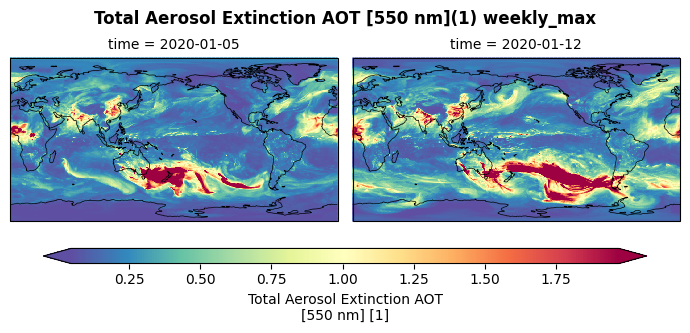

In [16]:
%%time
# ------------------------------------------------------------------
# Visualizing the evolution of Australian bushfire 
# ------------------------------------------------------------------

# 1) Plot the spatial facet map (e.g., the first two weeks)
print("Plotting...(It may take ~ 4 minutes)")

pmap = sel_var_weekly_max.isel(time=[0,1]).plot(transform=ccrs.PlateCarree(),  # the data's projection
             col='time', col_wrap=2, robust=True, # multiplot settings
             cmap=plt.cm.Spectral_r, 
             cbar_kwargs={
            "orientation": "horizontal",
            "shrink": 0.9,
            "aspect": 40,
            "pad": 0.1,
                         },
            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=180)})  # the plot's projection
            # shift the original central longitude from 0 to 180 


# We have to set the map's options on all axes

for ax in pmap.axes.flat:
    ax.coastlines(resolution="110m",linewidth=0.5)
    
# Plot main title
main_title = "{}{} weekly_max".format(sel_var_longname, sel_var_unit) 
plt.suptitle(main_title, fontweight='bold')

# Save the plot 
file_dir = '.'
figFile_plot = "{}/map.{}.selected_time.{}.png".format(file_dir, "M2T1NXAER", sel_var_shortname)
plt.savefig(figFile_plot, dpi=200)
print(" Pick up your figure ", figFile_plot) 

2) Plot the time series of daily mean averaged over the globe (Figure 2)

stat:
       TOTEXTTAU
count  12.000000
mean    0.136681
std     0.011766
min     0.115233
25%     0.129005
50%     0.141344
75%     0.144894
max     0.148424
 Pick up your figure  ./timeseries.M2T1NXAER.selected_time.TOTEXTTAU.png
CPU times: user 1.29 s, sys: 315 ms, total: 1.61 s
Wall time: 654 ms


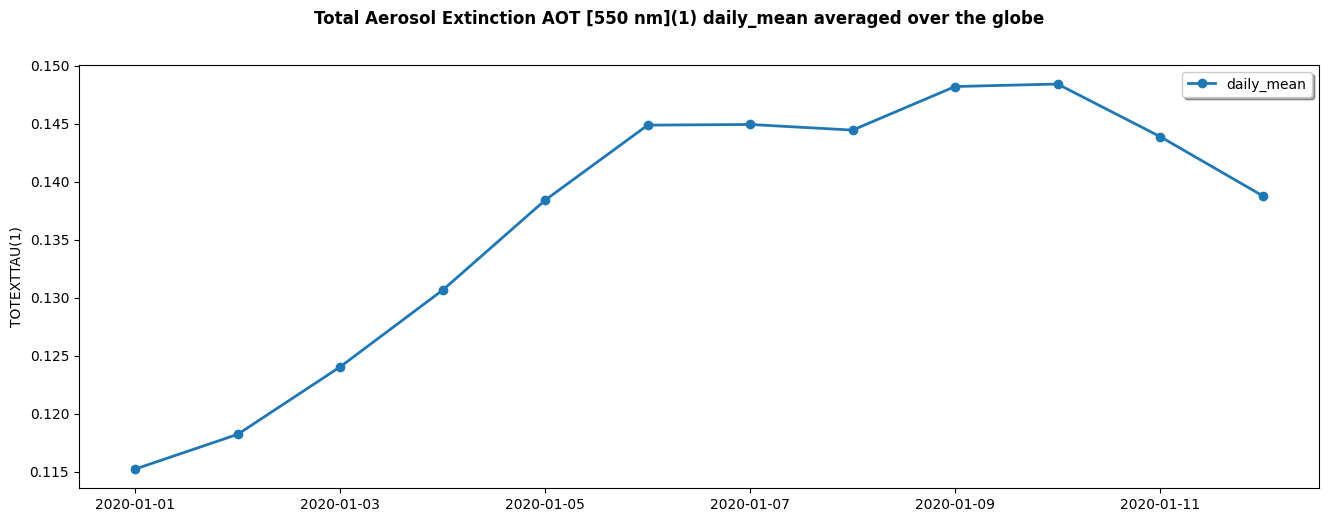

In [17]:
%%time

# 2) Plot the time series of daily mean averaged over the globe 

fig, ax = plt.subplots(figsize=(16,5.5))
sel_var_daily_mean_region = sel_var_daily_mean.groupby('time').mean(dim=['lat','lon'],skipna=True)

# Convert to dataframe 
plotdata = sel_var_daily_mean_region.to_dataframe()

# List the statistics
stat = plotdata.describe()
print("stat:")
print(stat)

# Plot time series
ax.plot(plotdata,label='daily_mean', marker="o", linewidth=2)
ax.legend(shadow=True, fancybox=True)

# Plot main title and xy labels
main_title = "{}{} daily_mean averaged over the globe".format(sel_var_longname, sel_var_unit) 
plt.suptitle(main_title, fontweight='bold')
ax.set_ylabel(sel_var_shortname+sel_var_unit)

# Save the plot
figFile_plot = "{}/timeseries.{}.selected_time.{}.png".format(file_dir, "M2T1NXAER", sel_var_shortname)
plt.savefig(figFile_plot, dpi=200)
print(" Pick up your figure ", figFile_plot) 